In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

In [11]:

#load the data set
new = pd.read_csv("C:/Data/new.csv")
AAPL = pd.read_csv("C:/Data/yfinance_data/Data/AAPL.csv")
# Load datasets
#Amazone = pd.read_csv("C:/Data/yfinance_data/Data/AMZN.csv")
#Google = pd.read_csv("C:/Data/yfinance_data/Data/GOOG.csv")
#Meta = pd.read_csv("C:/Data/yfinance_data/Data/META.csv")
#Nvda=pd.read_csv("C:/Data/yfinance_data/Data/NVDA.csv")

print(new.head())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

In [12]:
new['date'] = pd.to_datetime(new['date'], errors='coerce')
AAPL['Date'] = pd.to_datetime(AAPL['Date'],errors='coerce')

In [17]:
print(AAPL.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [13]:
#EXTRACT DATE ONLY
new['news_date'] = new['date'].dt.date
AAPL['Date_only'] = AAPL['Date'].dt.date

In [16]:
trading_days = AAPL['Date'].sort_values().unique()

In [18]:
new['date'] = pd.to_datetime(new['date']).dt.tz_localize(None)
AAPL['Date'] = pd.to_datetime(AAPL['Date']).dt.tz_localize(None)

In [20]:
new['date'].isna().sum()

np.int64(1351341)

In [21]:
new[new['date'].isna()]

,Unnamed: 0,headline,url,publisher,date,stock,news_date
10,10,30 Stocks Moving in Friday's Pre-Market Session,https://www.benzinga.com/news/20/05/16092879/3...,Lisa Levin,NaT,A,NaT
11,11,SVB Leerink Maintains Outperform on Agilent Te...,https://www.benzinga.com/news/20/05/16092270/s...,vishwanath@benzinga.com,NaT,A,NaT
12,12,8 Stocks Moving In Thursday's After-Hours Session,https://www.benzinga.com/news/20/05/16089803/8...,Tyree Gorges,NaT,A,NaT
13,13,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16089218/a...,Benzinga Newsdesk,NaT,A,NaT
14,14,Agilent Technologies Q2 Adj. EPS $0.71 Beats $...,https://www.benzinga.com/news/earnings/20/05/1...,Benzinga Newsdesk,NaT,A,NaT
...,...,...,...,...,...,...,...
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,NaT,ZX,NaT
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,NaT,ZX,NaT
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,NaT,ZX,NaT
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,NaT,ZX,NaT


In [23]:
new = new.dropna(subset=['date'])

In [24]:
new['date'] = pd.to_datetime(new['date'], errors='coerce')
AAPL['Date'] = pd.to_datetime(AAPL['Date'], errors='coerce')

In [25]:
new = new.dropna(subset=['date'])
AAPL = AAPL.dropna(subset=['Date'])

In [26]:
new['date'] = new['date'].dt.tz_localize(None)
AAPL['Date'] = AAPL['Date'].dt.tz_localize(None)

In [27]:
new = new.sort_values('date')
AAPL = AAPL.sort_values('Date')

In [28]:
new['date'] = pd.to_datetime(new['date'])
AAPL['Date'] = pd.to_datetime(AAPL['Date'])

new = new.sort_values('date')
AAPL = AAPL.sort_values('Date')

result = pd.merge_asof(
    new,
    AAPL,
    left_on='date',
    right_on='Date',
    direction='forward'
)

In [29]:
trading_days = pd.to_datetime(AAPL['Date']).drop_duplicates().sort_values()

s = pd.Series(trading_days, index=trading_days)

def align(date):
    date = pd.to_datetime(date)
    future_days = trading_days[trading_days >= date]
    return future_days.iloc[0] if len(future_days) else None

new['aligned_date'] = new['date'].apply(align)

In [33]:
#Apply sentiment scoring
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

new['sentiment'] = new['headline'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [35]:
#Aggregate Daily Sentiment
daily_sentiment = new.groupby(['stock', 'aligned_date'])['sentiment'].mean().reset_index()

In [40]:
#Calculate Daily Stock Returns
AAPL = AAPL.sort_values('Date')

AAPL['daily_return'] = AAPL['Close'].pct_change() * 100

In [38]:
print(AAPL.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Date_only'], dtype='str')


In [44]:
#Merge Sentiment + Stock Data
merged = pd.merge(
    daily_sentiment,
    AAPL,
    left_on='aligned_date',
    right_on='Date',
    how='inner'
)

In [45]:
#Correlation Analysis
from scipy.stats import pearsonr

corr, p_value = pearsonr(merged['sentiment'], merged['daily_return'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.021942288056147567
P-value: 4.063737578751047e-06


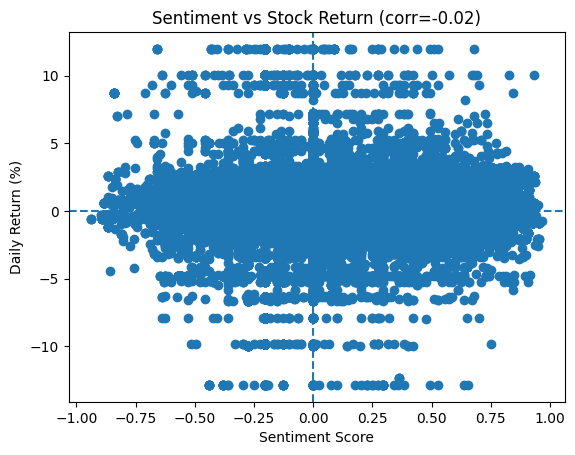

In [46]:
#Scatter Plot
import matplotlib.pyplot as plt

plt.scatter(merged['sentiment'], merged['daily_return'])
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return (%)")
plt.title(f"Sentiment vs Stock Return (corr={corr:.2f})")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.show()

In [47]:
#Sentiment Classification
def label_sentiment(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    return "Neutral"

merged['sentiment_label'] = merged['sentiment'].apply(label_sentiment)

In [48]:
#Bar Chart (Average Return per Sentiment)
avg_returns = merged.groupby('sentiment_label')['daily_return'].mean().reset_index()

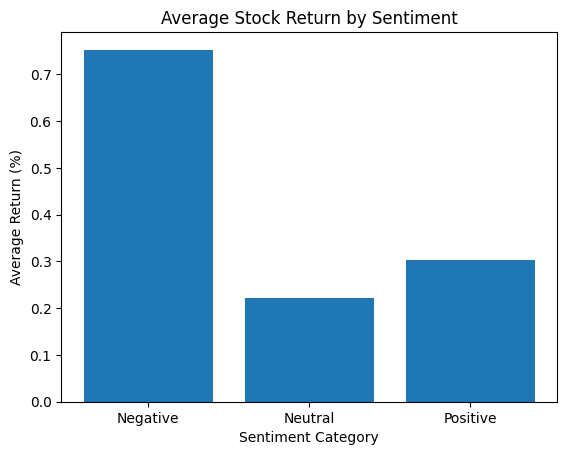

In [49]:
plt.bar(avg_returns['sentiment_label'], avg_returns['daily_return'])
plt.title("Average Stock Return by Sentiment")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Return (%)")
plt.show()

The analysis shows the relationship between news sentiment and stock price movements. The Pearson correlation coefficient indicates whether sentiment and returns move together or not. A positive value suggests that positive news tends to be followed by higher returns, while a negative value suggests the opposite. If the value is close to zero, it means the relationship is weak or inconsistent.

However, stock prices are influenced by many external factors beyond news sentiment, such as macroeconomic conditions, investor behavior, and market trends. Another limitation is timing mismatch, since news impact may appear with a delay rather than on the same trading day. Therefore, sentiment alone cannot fully explain stock price movements.